<a href="https://colab.research.google.com/github/jaison-leonardo/projects-ML-DL-iue/blob/main/Spark_Wisconsin_Breast_Cancer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import BinaryClassificationEvaluator

from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
spark = SparkSession.builder.appName("MedicinaBigData").getOrCreate()

# Dataset de cáncer de mama
data = load_breast_cancer(as_frame=True)

pdf = data.frame.copy()
pdf["label"] = pdf["target"]
pdf = pdf.drop(columns=["target"])

pdf.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [4]:
sdf = spark.createDataFrame(pdf)
sdf.show(5)

+-----------+------------+--------------+---------+---------------+----------------+--------------+-------------------+-------------+----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+------------+-------------+---------------+----------+----------------+-----------------+---------------+--------------------+--------------+-----------------------+-----+
|mean radius|mean texture|mean perimeter|mean area|mean smoothness|mean compactness|mean concavity|mean concave points|mean symmetry|mean fractal dimension|radius error|texture error|perimeter error|area error|smoothness error|compactness error|concavity error|concave points error|symmetry error|fractal dimension error|worst radius|worst texture|worst perimeter|worst area|worst smoothness|worst compactness|worst concavity|worst concave points|worst symmetry|worst fractal dimension|label|
+-----------+-

In [5]:
sdf.groupBy("label").count().show()

+-----+-----+
|label|count|
+-----+-----+
|    0|  212|
|    1|  357|
+-----+-----+



In [6]:
feature_cols = [c for c in sdf.columns if c != "label"]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [7]:
# Creación del pipeline
rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    numTrees=100,
    seed=42
)

pipeline = Pipeline(stages=[assembler, rf])

In [8]:
# Entrenamiento y predicción
train, test = sdf.randomSplit([0.8, 0.2], seed=42)

model = pipeline.fit(train)
pred = model.transform(test)

pred.select("label", "prediction", "probability").show(5)

+-----+----------+--------------------+
|label|prediction|         probability|
+-----+----------+--------------------+
|    1|       1.0|[0.07782941748777...|
|    1|       1.0|[0.01678537021267...|
|    1|       1.0|[0.00653286215380...|
|    1|       1.0|[0.00595080857290...|
|    1|       1.0|[0.00611887579979...|
+-----+----------+--------------------+
only showing top 5 rows


In [9]:
# Evaluación
evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

auc = evaluator.evaluate(pred)

print("AUC:", auc)

AUC: 0.9984615384615384


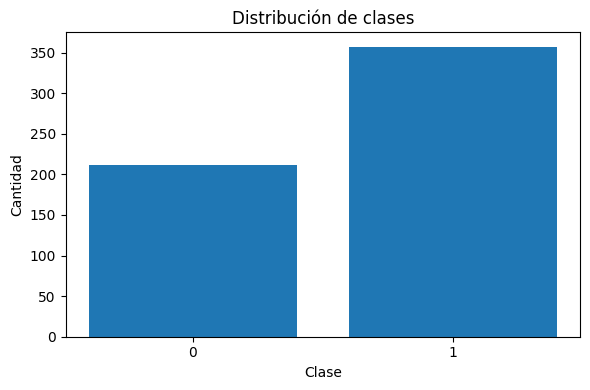

In [10]:
counts = sdf.groupBy("label").count().toPandas()

plt.figure(figsize=(6,4))
plt.bar(counts["label"].astype(str), counts["count"])
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()